In [100]:
from xyzrender import load, render, orient, build_config
from xyzrender.types import VectorArrow
import numpy as np
from automol import Geometry
from learn_vrc_tst import geom, View
from scipy.spatial.transform import Rotation
from pathlib import Path

In [101]:
file_in = "tert-butanol-in.xyz"
file_out = "tert-butanol.xyz"
file_svg = Path(file_out).with_suffix(".svg")

In [102]:
# Regular tetrahedron unit vectors: one vertex on +z (O, "straight up" from the
# central carbon), the other three as a downward tripod (the tert-butyl carbons).
# v1 is the tripod vector with y = 0, tilted toward -x ("left"), matching the O-H tilt.
v0 = np.array([0.0, 0.0, 1.0])
v1 = np.array([-2 * np.sqrt(2) / 3, 0.0, -1 / 3])
v2 = np.array([np.sqrt(2) / 3, np.sqrt(6) / 3, -1 / 3])
v3 = np.array([np.sqrt(2) / 3, -np.sqrt(6) / 3, -1 / 3])

XY_DIST = 1.5  # C-O, C-C bond length (Angstrom)
XH_DIST = 1.2  # X-H bond length (Angstrom)

c0 = np.zeros(3)
o = XY_DIST * v0
c1 = XY_DIST * v1
c2 = XY_DIST * v2
c3 = XY_DIST * v3

# O-H: 109.5 degree angle from the O-C0 bond, tilted left, in the same plane as C1.
h_o = o + XH_DIST * np.array([-2 * np.sqrt(2) / 3, 0.0, 1 / 3])

# Each methyl carbon's three H's take the tetrahedral directions *not* used for its
# own bond back to C0 (the diamond-lattice "opposite set" rule). This automatically
# gives every methyl group one H pointing straight down (-v0), matching a true
# diamond-crystal layout, with an exact 109.5 degree angle everywhere.
dirs = {"v0": v0, "v1": v1, "v2": v2, "v3": v3}


def methyl_hydrogens(c_pos, back_key):
    """Three H positions for a methyl carbon bonded back to C0 via `back_key`."""
    h_dirs = [-dirs[k] for k in ("v0", "v1", "v2", "v3") if k != back_key]
    return [c_pos + XH_DIST * d for d in h_dirs]


h1a, h1b, h1c = methyl_hydrogens(c1, "v1")
h2a, h2b, h2c = methyl_hydrogens(c2, "v2")
h3a, h3b, h3c = methyl_hydrogens(c3, "v3")

symbols = ["C", "O", "H", "C", "H", "H", "H", "C", "H", "H", "H", "C", "H", "H", "H"]
coordinates = np.array(
    [c0, o, h_o, c1, h1a, h1b, h1c, c2, h2a, h2b, h2c, c3, h3a, h3b, h3c]
)
geo = Geometry(symbols=symbols, coordinates=coordinates)
geom.write_xyz_file(geo, file_in)

In [103]:
geo = geom.read_xyz_file(file_in)
geo = geom.rotate(geo, rot=Rotation.from_euler("xy", [-90, -30], degrees=True))
geo = geom.rotate(geo, rot=Rotation.from_euler("x", [40], degrees=True))
geom.write_xyz_file(geo, file_out)

view = View()
view.add_geometry(geo, label=True)
view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [104]:
cfg = build_config(
  config_name="flat", orient=False, atom_scale=3, bond_width=25,
  bond_color="#000000", atom_stroke_width=3, hy=True, bo=False, fog=False
)

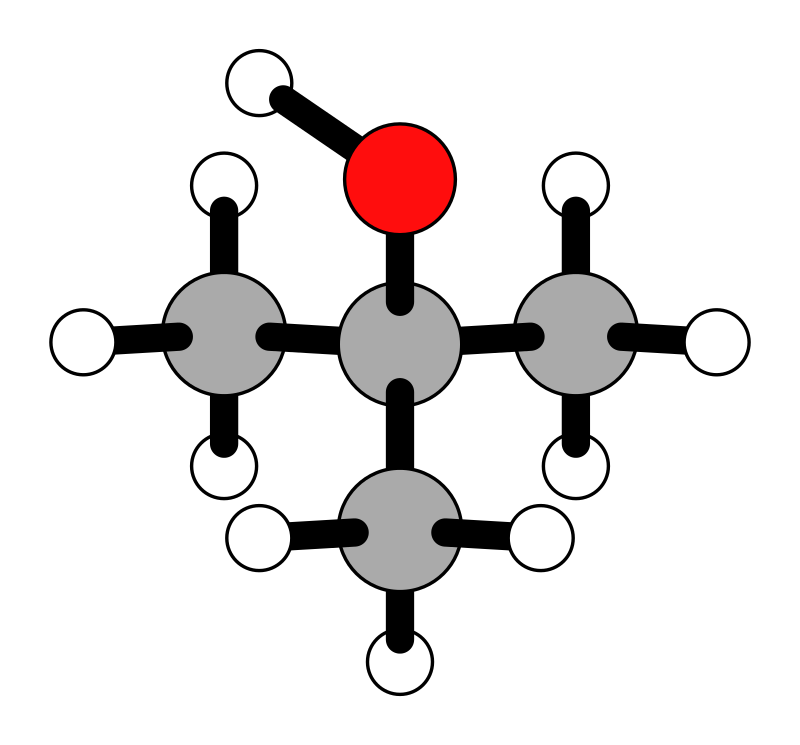

In [105]:
mol = load(file_out)
render(mol, output=file_svg, config=cfg)